In [1]:
import numpy as np
from sklearn import linear_model
import torch
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

plt.style.use('dark_background')

/home/pt202342/miniconda3/envs/id-diff/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [10]:


def draw_heatmap(df, title):
    plt.figure(figsize=(15,15))
    piv = pd.pivot_table(df, values="avg_dim",index=["k_n"], columns=["deltas"], fill_value=0)
    ax = sns.heatmap(piv, square=True, cmap="viridis", annot=True)
    plt.setp( ax.xaxis.get_majorticklabels(), rotation=90 )
    plt.tight_layout()
    plt.title(title)
    plt.show()

In [11]:
ALL_DELTAS = [0.00015625, 0.0003125, 0.000625]
ALL_BACKBONES = ["maf"]#, "rqnsf"]
ALL_KNS = [
    "e2/uniform_pca", "e3/gaussian_pca", "e1/spiral_pca", "e4/sphere_pca_radius025",
    "e4/sphere_pca_radius050", "e4/sphere_pca_radius100", "e6/exp_pca", "e7/crescent_moon_pca",
    "e1/sampled_fmnist_step1", "e1/sampled_fmnist_step2", "e1/sampled_fmnist_step3",
    "e1/sampled_fmnist_step4", "e1/sampled_fmnist_step5", "e1/sampled_fmnist_step6",
    "e1/sampled_fmnist_step7", "e1/sampled_fmnist_step8", "e1/sampled_fmnist_step9",
    "e1/sampled_fmnist_step10", "e1/sampled_fmnist_step11", "e1/sampled_fmnist_step12" ]

results = []
# dataset_prefix="quantized_uniform"
# 
# "e4/sphere_pca_radius200"


# /home/pt202342/projects/lidl/results/maf/e2/uniform_pca/0.00015625;0.0003125;0.000625/lls.torch
for backbone in ALL_BACKBONES:
    for k_n in  ALL_KNS:
        x = torch.load(f"/home/pt202342/projects/lidl/results/{backbone}/{k_n}/0.00015625;0.0003125;0.000625/lls.torch")
        for i in range(0, (len(ALL_DELTAS) - 2)):
            deltas = np.array(ALL_DELTAS[i: i+3])
            lls = x [i:i + 3].transpose()
            total_dim = 2

            dims = list()
            for i in range(lls.shape[0]):
                good_inds = ~np.logical_or(np.isnan(lls[i]), np.isinf(lls[i]))
                if ~good_inds.all():
                    print(
                        f"[WARNING] some log likelihoods are incorrect, deltas: {deltas}")
                ds = np.log(deltas[good_inds])
                ll = lls[i][good_inds]
                if ll.size < 2:
                    dims.append(np.nan)
                else:
                    regr = linear_model.LinearRegression()
                    regr.fit(ds.reshape(-1, 1), ll)
                    regr.predict(ds.reshape(-1, 1))
                    dims.append(total_dim - regr.coef_[0])
            results.append({
                "k_n": k_n,
                "avg_dim": np.mean(dims),
                "backbone": backbone,
                "deltas": str(deltas),
                "dims": dims})

In [12]:
df = pd.DataFrame(results)
df.to_json("aldi_lidl_results.json")
df.to_csv("aldi_lidl_results.csv", index=False)

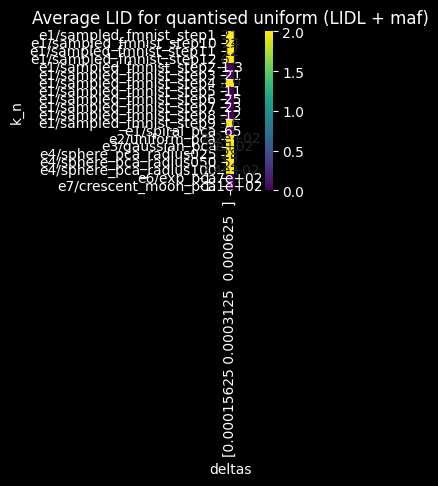

In [13]:


for backbone in ["maf"]:
    draw_heatmap(df[df["backbone"] == backbone], f"Average LID for quantised uniform (LIDL + {backbone})")

In [14]:
df

,k_n,avg_dim,backbone,deltas,dims
0,e2/uniform_pca,219.960210,maf,[0.00015625 0.0003125 0.000625 ],"[175.6520878305953, 277.16537308134923, 228.67..."
1,e3/gaussian_pca,195.640485,maf,[0.00015625 0.0003125 0.000625 ],"[187.678831853709, 223.60162137342218, 217.535..."
2,e1/spiral_pca,-64.928065,maf,[0.00015625 0.0003125 0.000625 ],"[-65.39069454793133, -62.442961443146245, -66...."
3,e4/sphere_pca_radius025,27.933767,maf,[0.00015625 0.0003125 0.000625 ],"[37.83631939458183, 21.48624522513217, 24.3589..."
4,e4/sphere_pca_radius050,51.733412,maf,[0.00015625 0.0003125 0.000625 ],"[75.27171971827383, 48.89850766342938, 52.6426..."
5,e4/sphere_pca_radius100,343.577425,maf,[0.00015625 0.0003125 0.000625 ],"[356.5884471798977, 336.8618114846956, 339.353..."
6,e6/exp_pca,-166.568928,maf,[0.00015625 0.0003125 0.000625 ],"[-168.52789227085762, -168.13305312514564, -16..."
7,e7/crescent_moon_pca,-112.291312,maf,[0.00015625 0.0003125 0.000625 ],"[-87.32980311894973, -121.4395377746551, -122...."
8,e1/sampled_fmnist_step1,21.468435,maf,[0.00015625 0.0003125 0.000625 ],"[16.188144930929997, 211.15784831505138, 51.54..."
9,e1/sampled_fmnist_step2,-1.274841,maf,[0.00015625 0.0003125 0.000625 ],"[18.234105580042254, -1.1718333781653882, 46.1..."


In [61]:
from pathlib import Path


def quantized_uniform(root_data_path, n_k) -> tuple[np.ndarray, np.ndarray]:

    train_path = Path(root_data_path) / \
        "quantized_uniform" / f"{n_k}" / "train"
    test_path = Path(root_data_path) / "quantized_uniform" / f"{n_k}" / "test"

    def load_subset(path):
        train_data = np.load(path / "data.npy")
        train_lid = np.load(path / "lid.npy")
        train_coefficients = np.load(path / "coefficients.npy")
        return (train_data, train_lid, train_coefficients)

    train_data = load_subset(train_path)
    test_data = load_subset(test_path)

    return train_data, test_data


data = quantized_uniform("/home/pt202342/projects/lid-benchmark-datasets/data", 3)
train_dataset = data[0][0]
val_dataset = data[0][0]
test_dataset = data[1][0]

train_dataset.shape, val_dataset.shape, test_dataset.shape

((10000, 2), (10000, 2), (3, 2))

## new format

In [7]:
import numpy as np
from sklearn import linear_model
import torch
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

plt.style.use('dark_background')


# ALL_DELTAS = [0.00015625, 0.0003125, 0.000625,0.00125,0.0025,0.005,0.01,0.02,0.04,0.08,0.16,0.32,0.64,1.28]
# ALL_BACKBONES = ["maf", "rqnsf"]
# ALL_KNS = [3, 5, 9, 17, 33, 65, 129, 257]

# results = []

# ALL_DELTAS = [0.00015625, 0.0003125, 0.000625]
ALL_DELTAS = [0.0039, 0.0078, 0.0156, 0.0312, 0.0625, 0.1250]
ALL_BACKBONES = ["maf"]#, "rqnsf"]
ALL_KNS = [
    "e2/uniform_pca", "e3/gaussian_pca", "e1/spiral_pca", "e4/sphere_pca_radius025",
    "e4/sphere_pca_radius050", "e4/sphere_pca_radius100", "e6/exp_pca", #"e7/crescent_moon_pca",
    "e1/sampled_fmnist_step1", "e1/sampled_fmnist_step2", "e1/sampled_fmnist_step3",
    "e1/sampled_fmnist_step4", "e1/sampled_fmnist_step5", "e1/sampled_fmnist_step6",
    "e1/sampled_fmnist_step7", "e1/sampled_fmnist_step8", "e1/sampled_fmnist_step9",
    "e1/sampled_fmnist_step10", "e1/sampled_fmnist_step11", "e1/sampled_fmnist_step12" ]

results = []

def load_subset(path):
        train_data = np.load(path / "dataset.npy")
        # train_lid = np.load(path / "lid.npy")
        # train_coefficients = np.load(path / "coefficients.npy")
        return (train_data.reshape(train_data.shape[0], -1), )


root_data_path = "/home/pt202342/projects/lid-benchmark-datasets/data/benchmarks_2024-12-09"
            
for backbone in ALL_BACKBONES:
    for k_n in  ALL_KNS:
        for i in range(0, (len(ALL_DELTAS) - 2)):
            deltas = np.array(ALL_DELTAS[i: i+3])
            
            # deltas_str = ';'.join([str(x) for x in ALL_DELTAS])
            deltas_str = '0.0039;0.0078;0.0156;0.0312;0.0625;0.1250'

            test_path = Path(root_data_path) / k_n.replace("/", "_") / "test"
            test_data = load_subset(test_path)

            x = torch.load(f"/home/pt202342/projects/lidl/results/{backbone}/{k_n}/{deltas_str}/lls.torch")
            lls = x.transpose()[:, i: i+3]
            # total_dim = 2
            total_dim = test_data[0].shape[1]

            dims = list()
            for i in range(lls.shape[0]):
                good_inds = ~np.logical_or(np.isnan(lls[i]), np.isinf(lls[i]))
                if ~good_inds.all():
                    print(
                        f"[WARNING] some log likelihoods are incorrect, deltas: {deltas}")
                ds = np.log(deltas[good_inds])
                ll = lls[i][good_inds]
                if ll.size < 2:
                    dims.append(np.nan)
                else:
                    regr = linear_model.LinearRegression()
                    regr.fit(ds.reshape(-1, 1), ll)
                    regr.predict(ds.reshape(-1, 1))
                    dims.append(total_dim - regr.coef_[0])
            results.append({
                "k_n": k_n,
                "avg_dim": np.mean(dims),
                "backbone": backbone,
                "deltas": str(deltas),
                "dims": dims})

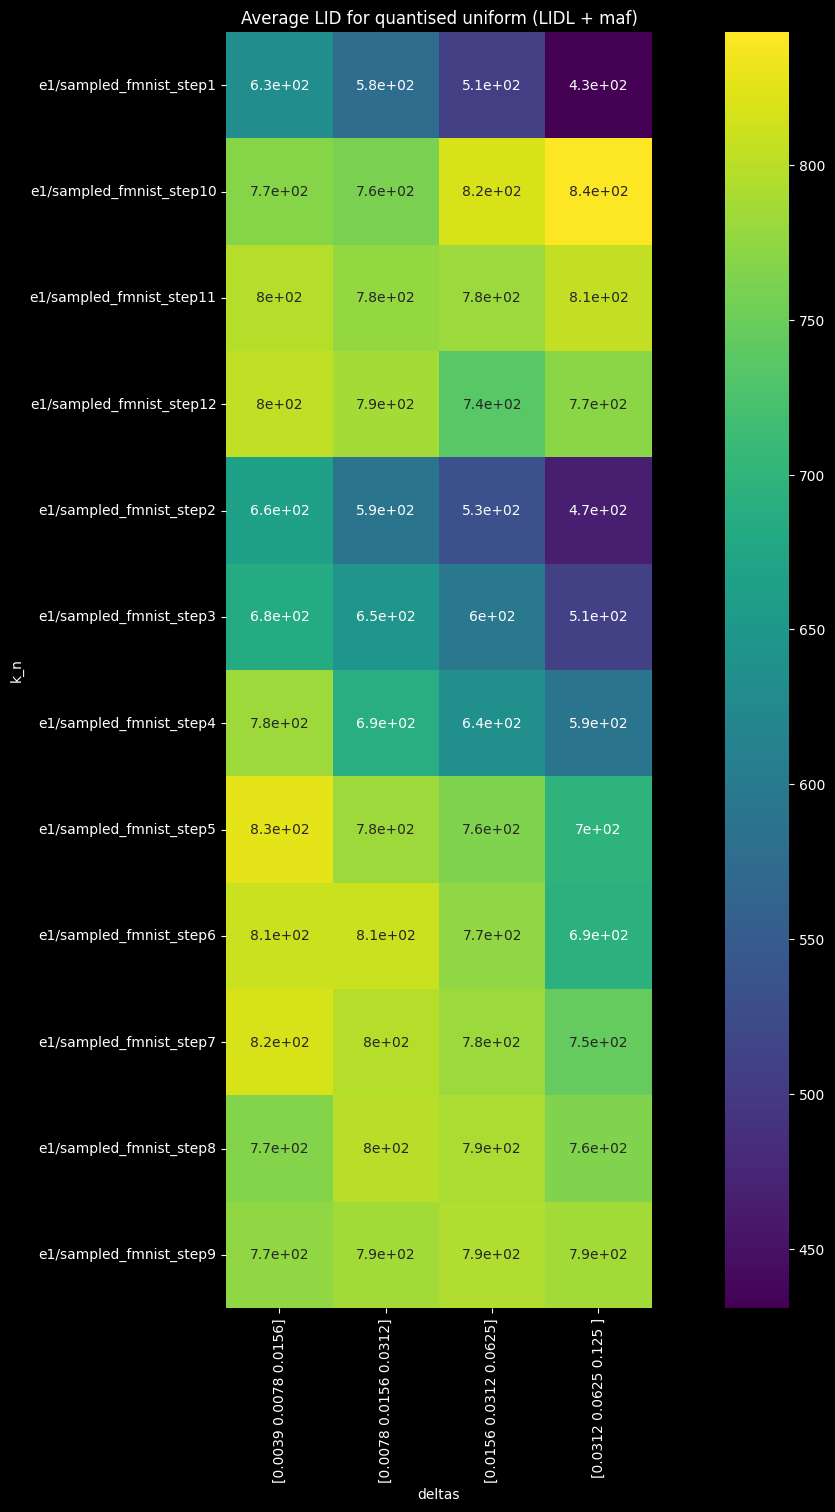

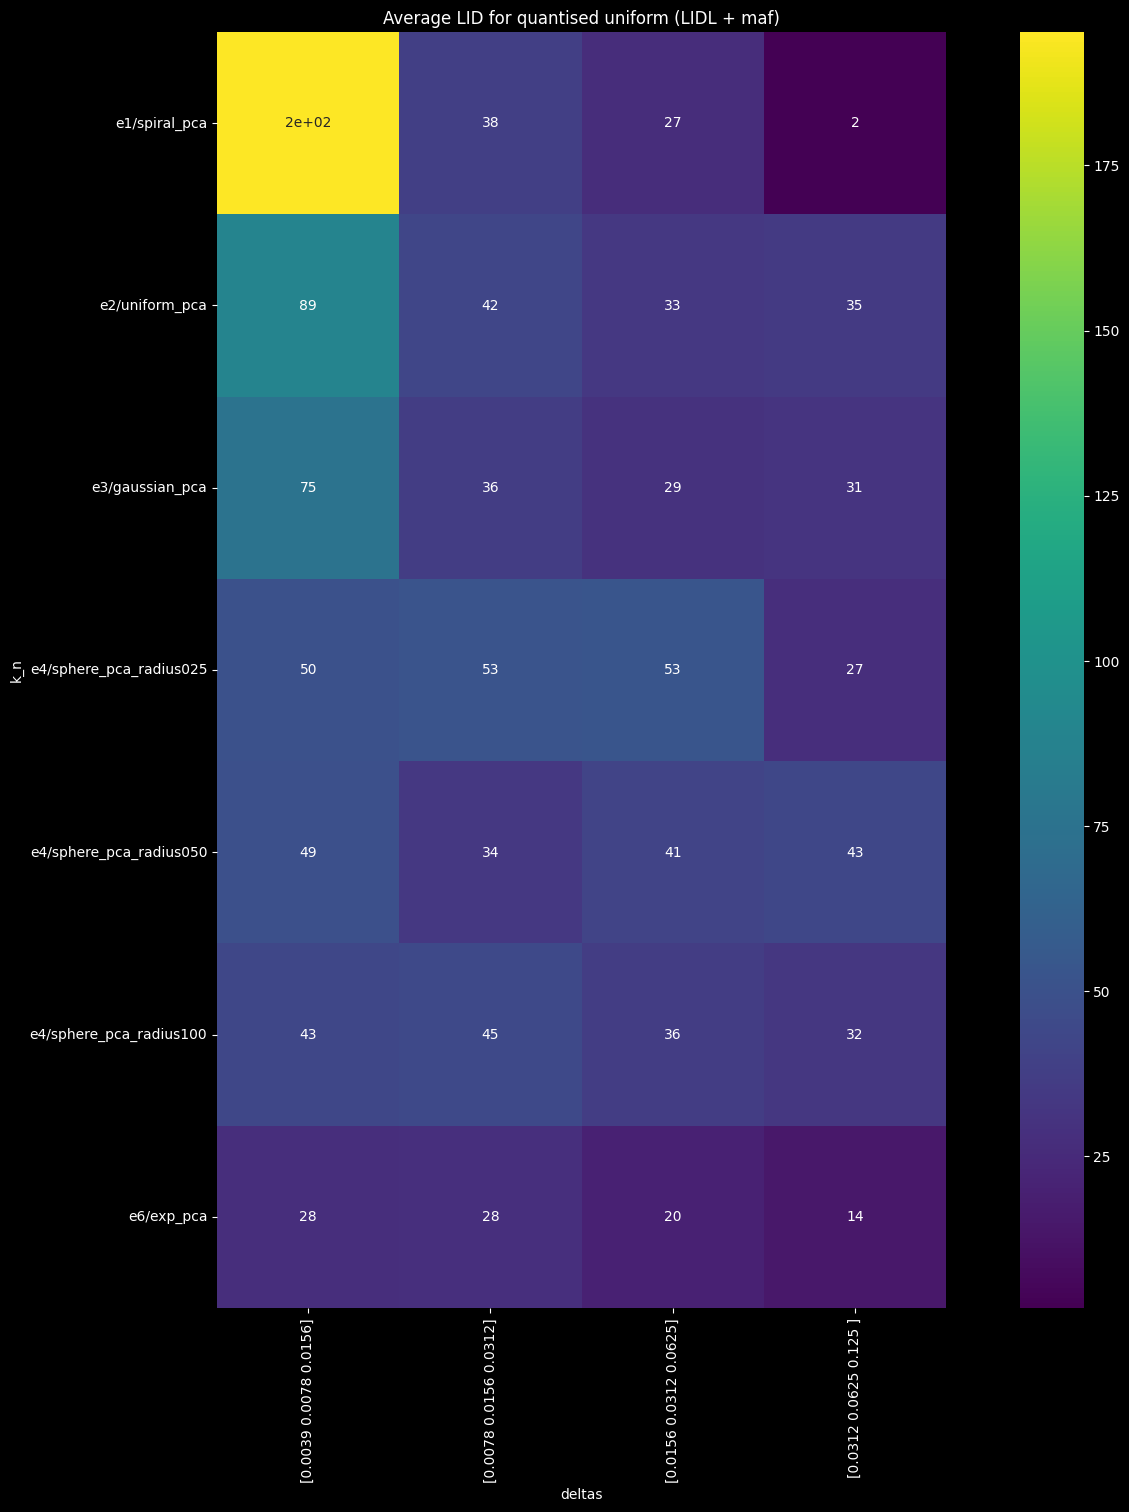

In [13]:
df = pd.DataFrame(results)
# df.to_json("results_quantised_uniform_val-is-train_trained-on-3-deltas.json")
# df.to_csv("results_quantised_uniform_val-is-train_trained-on-3-deltas.csv", index=False)

for backbone in ["maf"]:
    draw_heatmap(
        df[(df["backbone"] == backbone) & (df['k_n'].str.startswith('e1/sampled'))],
        f"Average LID for quantised uniform (LIDL + {backbone})"
        )
    
    draw_heatmap(
        df[(df["backbone"] == backbone) & ~(df['k_n'].str.startswith('e1/sampled'))],
        f"Average LID for quantised uniform (LIDL + {backbone})"
        )

In [9]:
pd.pivot_table(df, values="avg_dim",index=["k_n"], columns=["deltas"], fill_value=0)

deltas,[0.0039 0.0078 0.0156],[0.0078 0.0156 0.0312],[0.0156 0.0312 0.0625],[0.0312 0.0625 0.125 ]
k_n,,,,
e1/sampled_fmnist_step1,632.805736,575.773522,506.907867,430.805522
e1/sampled_fmnist_step10,768.467133,760.473911,818.352975,842.993733
e1/sampled_fmnist_step11,797.732580,775.849967,781.343330,805.748144
e1/sampled_fmnist_step12,803.764669,786.910848,736.550277,770.571984
e1/sampled_fmnist_step2,664.892668,589.507878,531.663322,465.322071
e1/sampled_fmnist_step3,683.146638,645.128982,595.057443,509.801132
e1/sampled_fmnist_step4,782.591969,689.157561,636.772035,590.144650
e1/sampled_fmnist_step5,826.640433,783.151491,764.038553,697.457993
e1/sampled_fmnist_step6,809.184657,809.879249,773.944143,693.364412


In [19]:
test_data[0].shape

(5000, 784)